# Landing Analysis

In [2]:
import os
import tomllib
import json
from datetime import date
from pathlib import Path

# Add the parent directory to the system path
import sys
sys.path.append(os.path.abspath('..'))

from src.data_loaders import read_telemetry_csv, load_runway_db
from src.parsers import extract_date_name_tacview
from src.transformer_plotter import (transform_telemetry, 
                                    touchdown_discovery,
                                    style_result_table,
                                    plot_landing_profile,
                                    touchdown_plotter)

# Load the configuration file
notebook_dir = Path.cwd()
config_path = notebook_dir.parent / "config.toml"
PROJECT_ROOT = config_path.parent.parent
with config_path.open('rb') as f:
    config = tomllib.load(f)

CSV_PATH            = PROJECT_ROOT / Path(config['input']['CSV_PATH'])
REF_PATH             = PROJECT_ROOT / Path(config["db_path"]["REF_PATH"])
RESULTS_DIR         = PROJECT_ROOT / Path(config["output"]["RESULTS_DIR"])


In [3]:
# Make the output directory
record_date, mission_name = extract_date_name_tacview(CSV_PATH)
if record_date is None:
    record_date = date.today().strftime("%Y%m%d")

plots_output_path = RESULTS_DIR/f"[{record_date}] {mission_name}"
detailed_td_path = plots_output_path/"Detailed Touchdowns"

detailed_td_path.mkdir(parents=True, exist_ok=True)

## 1. Load DB once

In [5]:
# 1. Load DB
runway_db = load_runway_db(REF_PATH)


In [7]:
runway_db[runway_db['iata_code'] == 'KUT']

,airport_name,iata_code,icao_code,runway_name,lat,lon
39206,David the Builder Kutaisi International Airport,KUT,UGKO,07,42.174801,42.467701
87348,David the Builder Kutaisi International Airport,KUT,UGKO,25,42.178501,42.497501


## 2. Touchdown Discovery

In [34]:
from importlib import reload
import pandas as pd

import src.transformer_plotter
import src.geographic_calculations
from src.transformer_plotter import touchdown_discovery
from src.geographic_calculations import find_closest_runway

reload(src.transformer_plotter)
reload(src.geographic_calculations)

<module 'src.geographic_calculations' from 'c:\\Users\\Fardad\\Desktop\\Landing Project\\Approach-Landing-Analyzer\\backend\\src\\geographic_calculations.py'>

In [35]:
# 2. Touchdown Discovery

# Read the telemetry data
df = read_telemetry_csv(CSV_PATH)
# clean and transform the data
df_sub = transform_telemetry(df)
# Discover the touch downs
df_result = touchdown_discovery(df_sub, runway_db)

In [36]:
df_result

,real_sortie_num,sortie_num,td_timestamp,td_timestamp_seconds,Name,Pilot,td_longitude,td_latitude,CAS_kt,AGL_ft,VS_fpm,vert_Acc_fpm2,vert_Jerk_fpm3,descent_quality,Airport,Runway,rwy_threshold_lat,rwy_threshold_long,touchdown_to_threshold_ft
0,1,1,2020-05-31 21:31:12.297144+00:00,2993.697145,F-16C_50,< 404C > Phoenix,145.726434,15.117754,173.930893,4.474660,-501.793887,9742.375563,9.105286e+06,"[-800 , -350]",PGSN,07,15.1145,145.718002,3198
1,2,2,2020-05-31 22:22:46.594193+00:00,6087.994194,F-16C_50,< 404C > Phoenix,144.924631,13.584309,172.038788,7.220391,-69.910946,1230.012131,1.564149e+06,"[-150 , 0]",PGUA,06L,13.5803,144.916000,3391
2,1,1,2020-05-31 22:30:08.793771+00:00,6530.193772,F-16C_50,< 404 > D1CE,144.919141,13.582125,173.448471,7.302242,-198.814415,1099.351501,1.825825e+06,"[-300 , -150]",PGUA,06L,13.5803,144.916000,1297
3,3,3,2020-05-31 22:41:09.093141+00:00,7190.493142,F-16C_50,< 404C > Phoenix,144.917117,13.580959,162.485626,7.312404,-190.040629,13731.981583,2.151845e+05,"[-300 , -150]",PGUA,06L,13.5803,144.916000,463
4,3,4,2020-05-31 22:41:14.693136+00:00,7196.093137,F-16C_50,< 404C > Phoenix,144.920947,13.582630,157.029709,7.002723,-387.061839,886.690063,2.198343e+06,"[-800 , -350]",PGUA,06L,13.5803,144.916000,1949


## 3. CSS Stylized Results Table

In [85]:
# 3. CSS Stylized Results Table
stylized_table = style_result_table(df_result, plots_output_path, record_date)
stylized_table

Exported styled Excel.
Exported styled HTML.
Exported table image.


,real_sortie_num,sortie_num,td_timestamp,Name,Pilot,CAS_kt,VS_fpm,Airport,Runway,touchdown_to_threshold_ft
0,1,1,2020-05-31 21:31:12.297144,F-16C_50,< 404C > Phoenix,173,-501,Saipan,07R,3127
1,2,2,2020-05-31 22:22:46.594193,F-16C_50,< 404C > Phoenix,172,-69,Andersen,06L,3427
2,1,1,2020-05-31 22:30:08.793771,F-16C_50,< 404 > D1CE,173,-198,Andersen,06L,1327
3,3,3,2020-05-31 22:41:09.093141,F-16C_50,< 404C > Phoenix,162,-190,Andersen,06L,496
4,3,4,2020-05-31 22:41:14.693136,F-16C_50,< 404C > Phoenix,157,-387,Andersen,06L,1985


## 4. Plot Approach Profiles

Sortie #4 of < 404C > Phoenix Took less than 6 second!


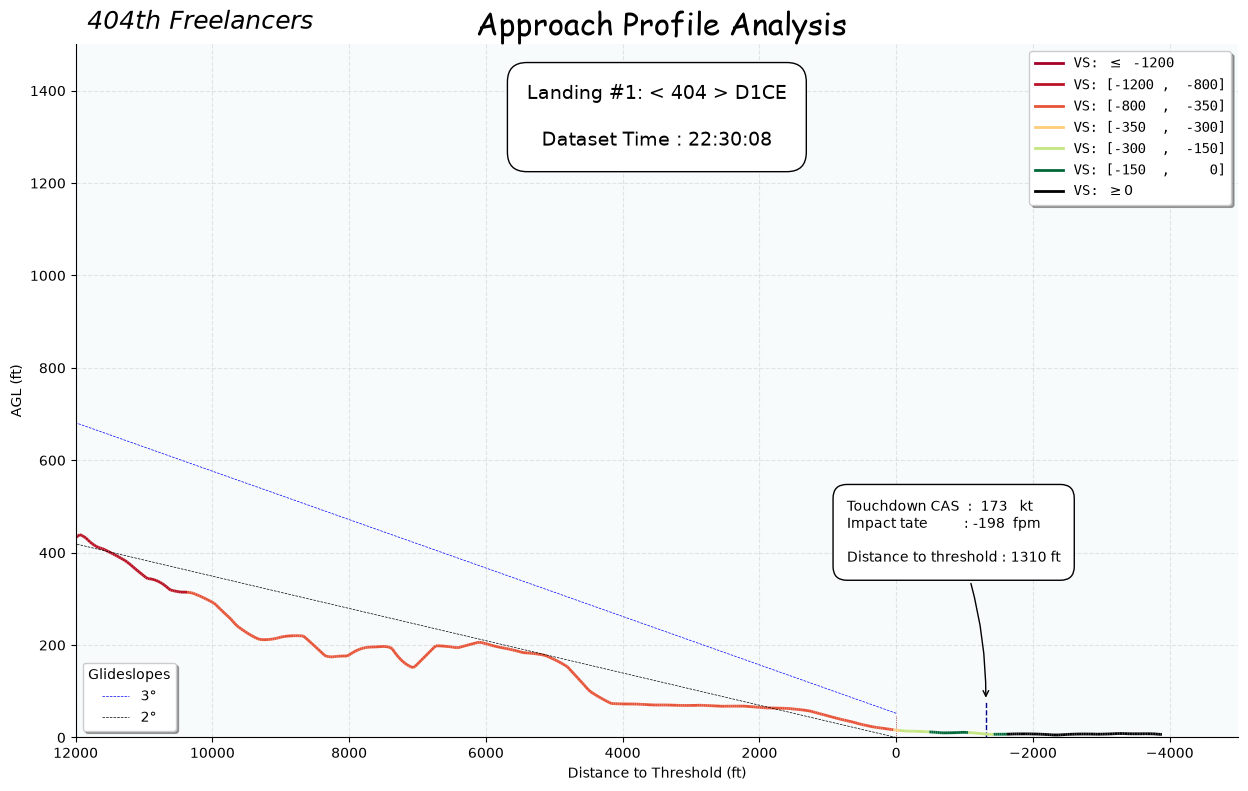

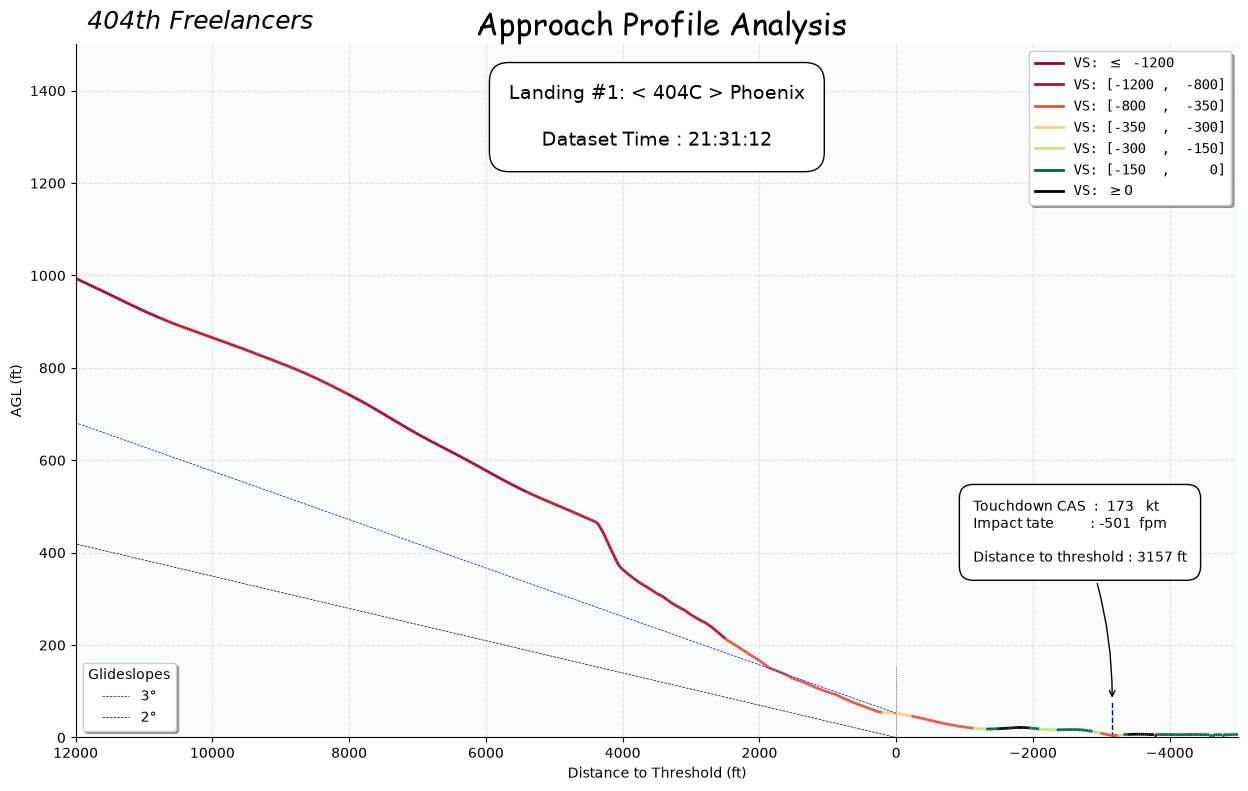

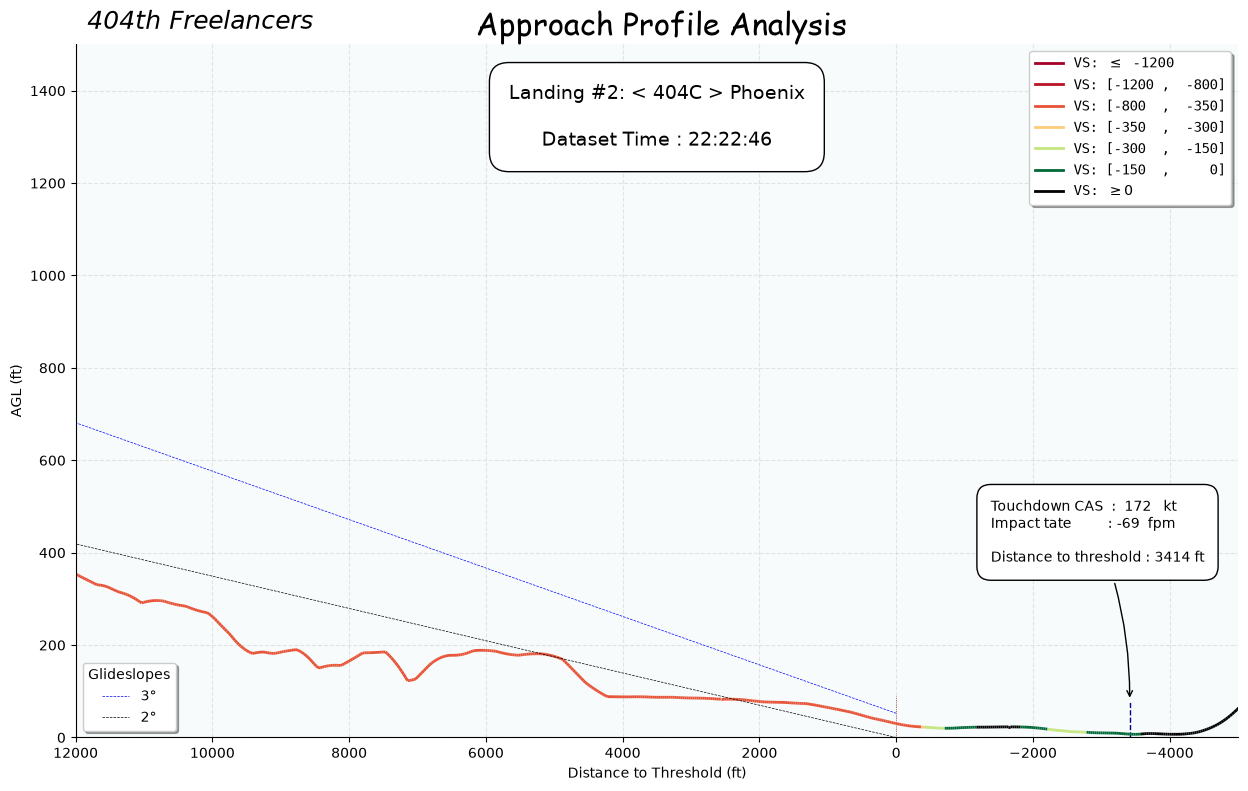

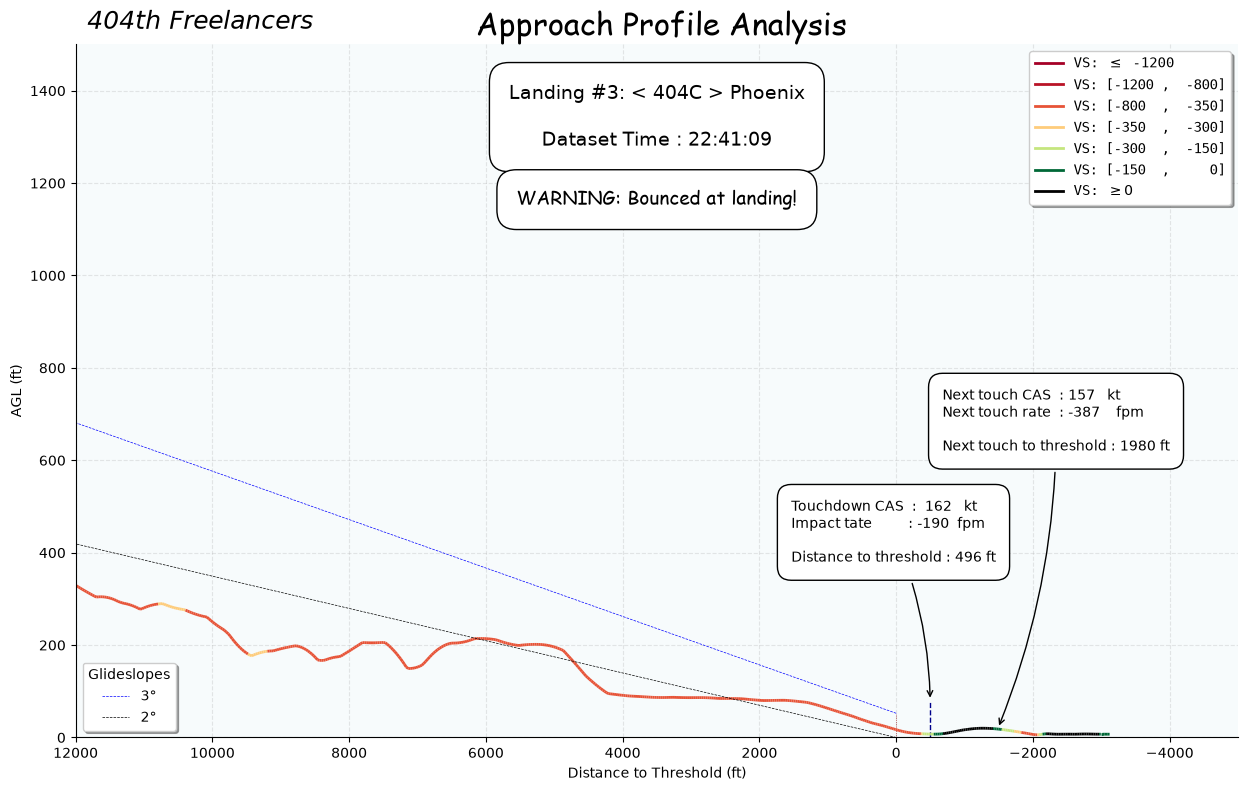

In [88]:
# 3. Plot/Export Profiles

for pilot in df_result['Pilot'].sort_values().unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        is_sortie = plot_landing_profile(df_sub, df_result, pilot, sortie_num, 
                                        plots_output_path, record_date)

## 5. Detailed Touchdowns (optional)

Sortie #4 of < 404C > Phoenix Took less than 6 second!


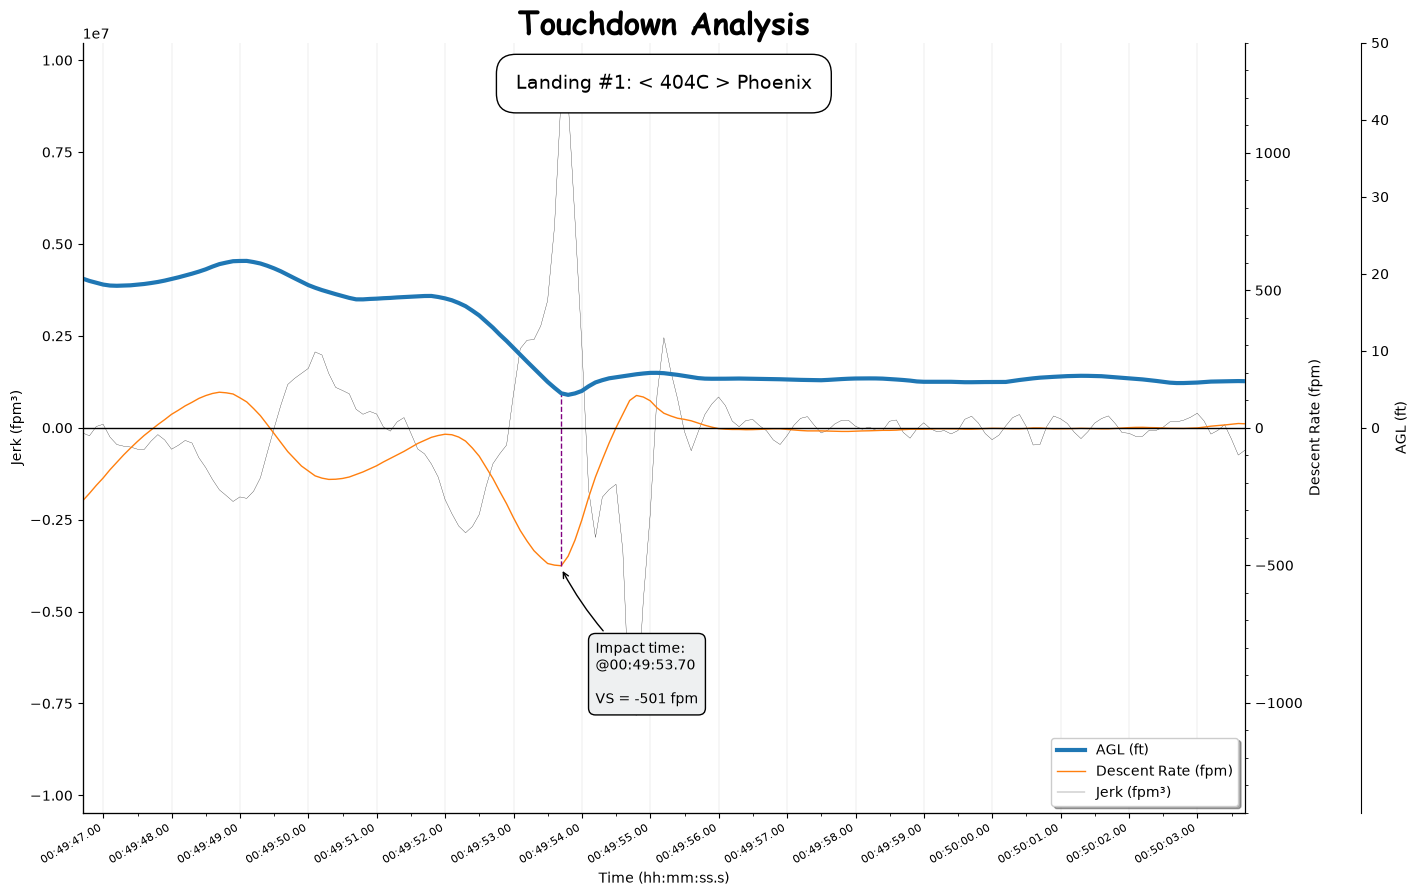

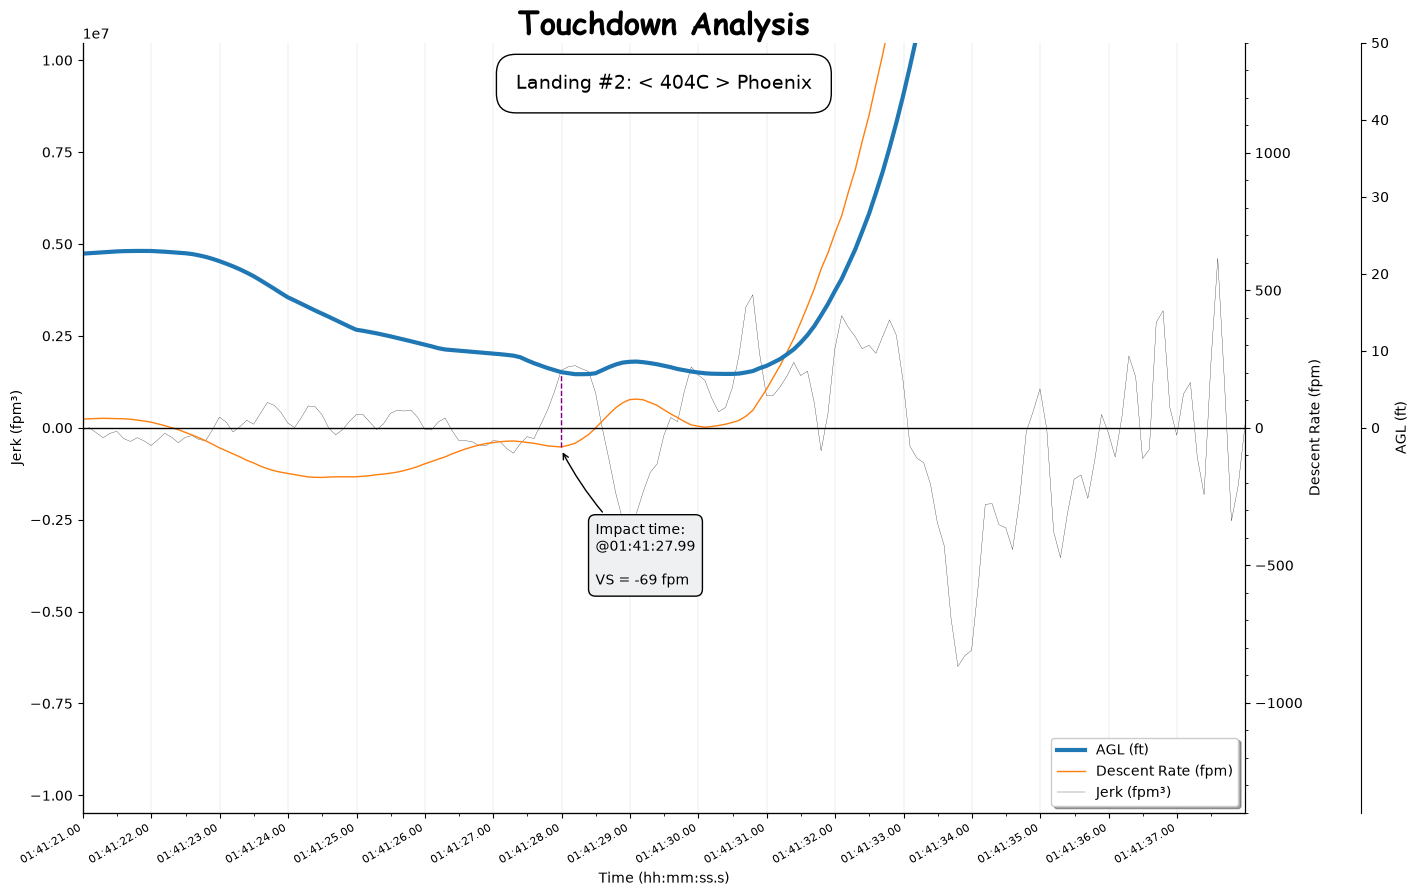

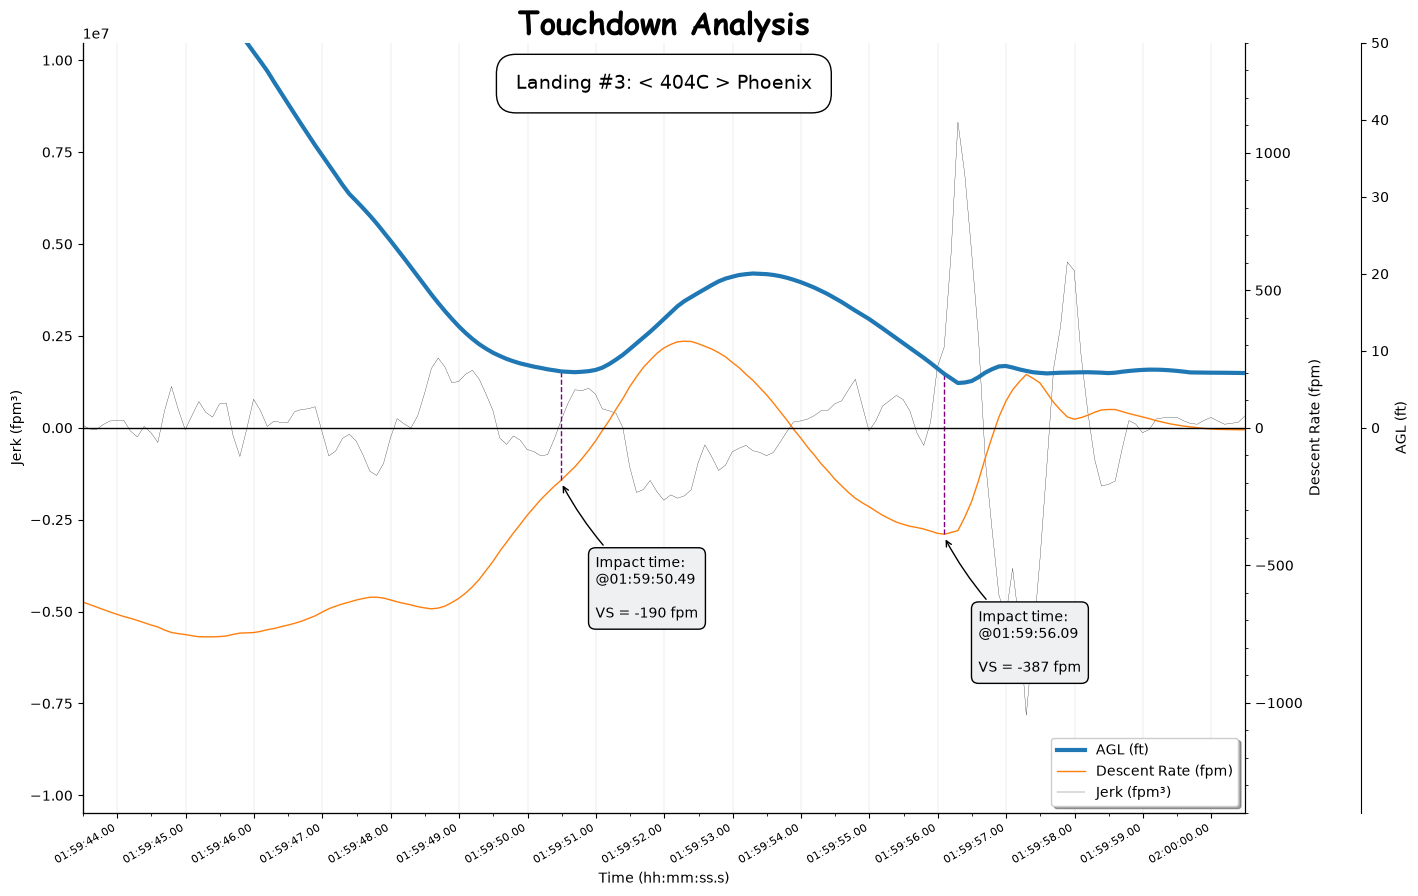

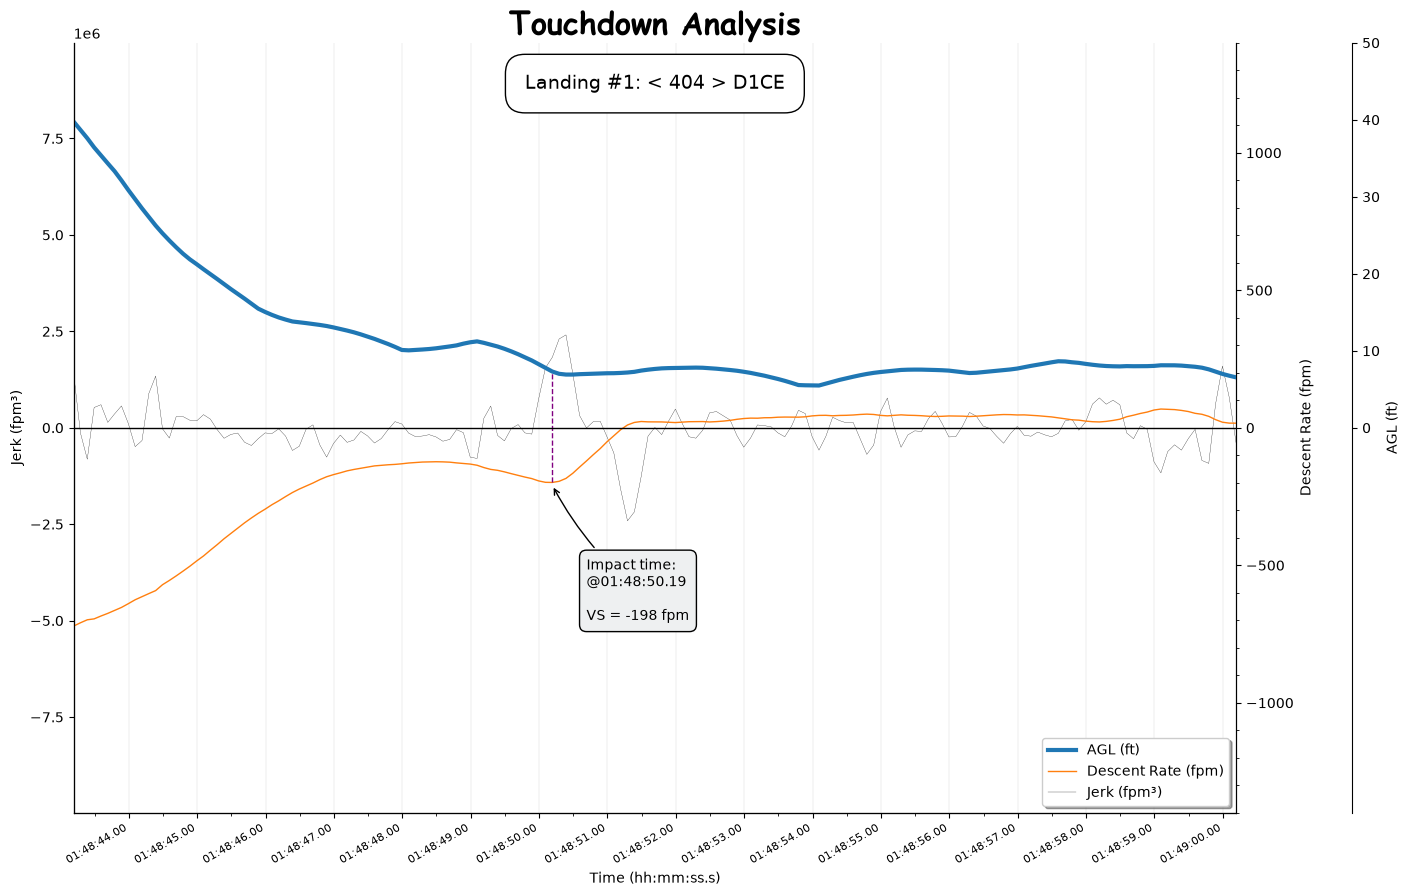

In [ ]:
# Plot/Export Touchdowns
for pilot in df_result['Pilot'].unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        touchdown_plotter(df_sub, df_result, pilot, sortie_num, detailed_td_path)